# (Try to) identify signals of gentrification from Airbnb data

_Code used to generate a paper for the GISRUK 2025 conference_.

Building on previous scripts (twitter sentiment and foursquare gentrification), this script uses data from [Inside AirBnB](https://insideairbnb.com/) and an LLM to see whether there might be indicators of the level of gentrification in an area. Ultimately we would like to repeat this for different years to see if gentrification patterns emerge.

In [1]:
import os
import re

import pandas as pd
import numpy as np
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from scipy.stats import zscore


from datetime import datetime

from IPython.core.pylabtools import figsize
# from fontTools.varLib.interpolatableHelpers import matching_for_vectors
#from pygments.lexers.textfmts import TodotxtLexer
from together import Together  # pip install together

from statsmodels.stats.inter_rater import fleiss_kappa

## Data

Data were downloaded for Edinburgh from [Inside AirBnB](https://insideairbnb.com/get-the-data/) from a snapshot taken on 23 September, 2024. I use the three 'details' files:
   - `listings.csv.gz`
   - `reviews.csv.gz`
   - `neighbourhoods.geojson`

The downloaded files need to be placed in a directory called [airbn-edinburgh](./airbnb-edinburgh) in the same directory as this script (not uploaded to github).

In [25]:
#from networkx.classes import restricted_view

listings = pd.read_csv("airbnb-edinburgh/listings.csv.gz")
reviews = pd.read_csv("airbnb-edinburgh/reviews.csv.gz")
neighbourhoods = gpd.read_file("airbnb-edinburgh/neighbourhoods.geojson")

# Use the lat/lon columsn to make the listings a geodataframe
listings = gpd.GeoDataFrame(listings, geometry=gpd.points_from_xy(listings.longitude, listings.latitude))

In [26]:
print(f"Have read {len(listings)} listings, {len(reviews)} reviews, and {len(neighbourhoods)} neighbourhoods.\n"
      f"They were last scraped on {listings.last_scraped.min()}.")

assert len(listings.last_scraped.unique()) == 1, "For some reason there are multiple last_scraped dates in the listings file."

Have read 5670 listings, 571175 reviews, and 111 neighbourhoods.
They were last scraped on 2024-12-14.


AssertionError: For some reason there are multiple last_scraped dates in the listings file.

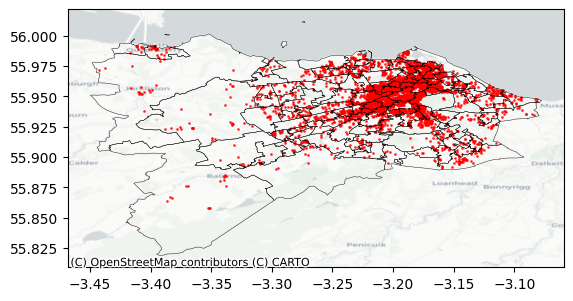

In [31]:
ax = neighbourhoods.plot(edgecolor="black", facecolor="none", linewidth=0.3, zorder=3)

# Plot the listings
listings.plot(ax=ax, color='red', markersize=1, alpha=0.7, zorder=2)

# Add a basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=neighbourhoods.crs.to_string(), zorder=0.5)

# Adjust the axis for a clean appearance
#ax.set_axis_off()

ax.figure.savefig("airbnb-edinburgh/listing_locations.png", dpi=300, bbox_inches="tight")

## Gentrification in Edinburgh

Initially just use the listing descriptions. Later we can try the reviews for the listings as well by merging on IDs


In [5]:
# We need a single 'text' column later. Combine the listing text and the neighbourhood overview
listings.loc[:, 'text'] = listings['description'] + " " + listings['neighborhood_overview']
# Drop Nan
listings = listings.dropna(subset=['text'])
listings.loc[:, ['id', 'description', 'neighborhood_overview', 'text']]

,id,description,neighborhood_overview,text
0,15420,"Stunning, spacious ground floor apartment minu...","The neighbourhood is in the historic New Town,...","Stunning, spacious ground floor apartment minu..."
1,24288,Upper level of duplex. Boho rustic-chic former...,"Boho, studenty, lively, cool neighbourhood",Upper level of duplex. Boho rustic-chic former...
2,38628,Self contained studio 6 minutes by train to Ed...,Quiet and easy access to outside. Fort Kinnair...,Self contained studio 6 minutes by train to Ed...
3,44009,My home is in a characterful old heritage-styl...,The flat is very central. It is 2mins from the...,My home is in a characterful old heritage-styl...
4,48645,The apartment is directly on the Royal Mile ab...,The Royal Mile is an area rich in culture and ...,The apartment is directly on the Royal Mile ab...
...,...,...,...,...
5607,1297677846029791880,"Beautiful colony apartment in Leith, a histori...",The flat is in Newhaven in northeastern Edinbu...,"Beautiful colony apartment in Leith, a histori..."
5613,1298623018458809245,This stunning and spacious apartment is locate...,"The Shore, Leith is a vibrant and friendly are...",This stunning and spacious apartment is locate...
5614,1298624204394067972,Ideally set right in the centre of Edinburgh a...,Our home is in the perfect location for all gu...,Ideally set right in the centre of Edinburgh a...
5637,1304241238154572962,✔ 2 x 2 bedroom apartments with 1 bathroom ava...,This JOIVY property is ideally located in Haym...,✔ 2 x 2 bedroom apartments with 1 bathroom ava...


### LLM gentrification function

Uses the Together.AI API.

A function that takes a batch of tweets and uses the Together API to classify them. The `system_prompt` variable contains the prompt that will be sent to the API; individual tweets are appended to this.

The LLM requires some parameter values. Here are the settings that chatGPT recommended (with defaults, that I decided not to use, in brackets)

1.	max_tokens:
	-	Recommendation: 50 (~1000 or more)
2.	temperature:
	-	Recommendation: 0.2 (0.7)
	-	Explanation: A lower temperature makes the model’s output more deterministic, which is ideal for scoring tasks where consistency is important.
3.	top_p:
	-	Recommendation: 0.9 (0.7)
	-	Explanation: This value balances the randomness and coherence of the output by considering tokens with a cumulative probability up to 90%.
4.	top_k:
	-	Recommendation: 40 (50)
	-	Explanation: Limits the model to consider the top 40 probable next tokens, which helps in generating relevant responses.
5.	repetition_penalty:
	-	Recommendation: 1.1 (1)
	-	Explanation: Slightly penalizes repeated tokens to prevent the model from producing redundant information.

In [6]:
# Create a log with the current time
LOG_FILE = os.path.join("logs", datetime.now().strftime("%Y-%m-%d-%H%M%S.log"))
def log(msg):
    with open(LOG_FILE, 'a') as f:
        f.write(msg)

In [8]:
def get_gentrification_scores(batch_tweets, system_prompt, client, batch_index=0, max_tokens=1000):
    """
    Retrieves gentrification scores for a batch of tweets using the Together AI API.

    Parameters
    ----------
    batch_tweets : pandas.DataFrame
        A DataFrame containing the tweets for the current batch.
        It must include a 'text' column with the tweet content.
    system_prompt : str
        The system prompt to be sent to the Together AI API.
        The tweet texts will be appended to this prompt.
    client : Together
        The Together client object to use for API calls.
    batch_index : int
        An optional starting index of the current batch.
        This is used to align the predicted sentiments with the original DataFrame indices.

    Returns
    -------
    ids : list of int
        A list of DataFrame indices corresponding to each tweet in the batch.
        These indices align with the main DataFrame from which this batch was drawn.
    sentiments : list of str
        A list of predicted gentrification scores for each tweet in the batch.
        Possible values are 1 (not suggestive of gentrification) to 5 (highly suggestive).
    explanations : list of str
        Explanations that the LLM returns giving it's reason for the the chosen score
        (these may or may not happen depending on the prompt, and the LLM's mood!)
    """

    # Prepare the list of tweets
    tweet_list = "\n".join([f"{idx + 1}. {tweet}"
                            for idx, tweet in enumerate(batch_tweets.text.values)])

    # Create the system prompt
    system_prompt = f"{system_prompt}\n\n{tweet_list}"
    #print("PROMPT:", system_prompt, "\n\n")

    # Prepare the messages
    messages = [
        {
            "role": "system",
            "content": system_prompt
        }
    ]

    # Call the API using parameters that ChatGPT recommends for this task
    response = client.chat.completions.create(
        #model="meta-llama/Llama-3.2-90B-Vision-Instruct-Turbo",
        model="meta-llama/Llama-3.3-70B-Instruct-Turbo",
        messages=messages,
        max_tokens=max_tokens,  # max length of output (in case I get the prompt wront and it talks for ages...)
        temperature=0.2,  # lower for more deterministic
        top_p=0.9,  # ??
        top_k=40,  # ??
        repetition_penalty=1,
        stop=["<|eot_id|>", "<|eom_id|>"],
        #truncate=130560,  # ??
        stream=False  # Set stream to False to get the full response
    )

    # Extract the assistant's reply and get the IDs and scores
    assistant_reply = response.choices[0].message.content.strip()

    # Useful to have a full log for debugging etc
    log(f"{datetime.now().strftime('%Y-%m-%d-%H%M%S')}\n" \
        f"**MESSAGE**\n{messages}\n" \
        f"**RESPONSE**\n{assistant_reply}\n\n")

    # Parse the IDs and scores (and, if available the explanation for the score)
    ids = []
    scores = []
    explanations = []

    # Regex pattern to extract the line number, score, and optional text from a line
    pattern = r'''
        ^\s*              # Start of line, allow leading whitespace
        (\d+)             # Capture Group 1: The line number
        \s*[.:]\s*        # A dot or colon with optional whitespace
        (?:Score:\s+)?    # Optionally match "Score:" followed by one or more spaces
        (\d+)             # Capture Group 2: The score (one or more digits)
        (?:\s*(.*))?      # Optional text after the score (Group 3)
        $                 # End of the line
    '''

    # Desipte being told not to, sometimes the reply starts with
    # 'Here are the scores:' or 'Here are the analyses:'
    # Remove that, and any whitespace at the start or end
    assistant_reply = re.sub(r'^\s*Here are the scores:\s*', '', assistant_reply).strip()
    assistant_reply = re.sub(r'^\s*Here are the analyses:\s*', '', assistant_reply).strip()

    # Analyse the reply line-by-line
    lines = assistant_reply.strip().split('\n')
    error_count = 0  # Return -1 on an error (and count the number of errors at the same time)
    for i, line in enumerate(lines):
        # Ignore lines that are empty once they have been stripped
        line = line.strip()
        if not line:
            continue

        # Try to match the line
        match = re.match(pattern, line, re.VERBOSE)
        if match:
            # Extract the index and score from the match groups
            index = int(match.group(1))
            score = int(match.group(2))
            explanation = match.group(3)
            log(f"{i} {line}\n\t{index},{score},{explanation}")
            # Validate the score range
            if 1 <= score <= 5:
                ids.append(index)
                scores.append(score)
                explanations.append(explanation)
            else:
                msg = f"Warning: Score {score} out of range on line {i}: '{line}'"
                print(msg)
                log(msg)
                error_count += 1
        else:
            msg = f"\n*********************\n" \
                  f"Warning: Invalid format on line {i}: '{line}'.\n" \
                  f"The full response was: \n{assistant_reply}\n" \
                  f"*********************\n"
            print(msg)
            log(msg)
            error_count += 1
            break

        if index-1 >= len(batch_tweets):
            msg = f"Found {index} tweets, but there are more lines. Assuming remaining lines are junk and ignoring them."
            log(msg)
            print(msg)
            break

    if error_count > 0:
        # There was an error, set scores to -1 and assume tweet IDs from
        # 1 to len(batch_tweets).
        scores = [-1] * len(batch_tweets)
        ids = [x + 1 for x in range(len(batch_tweets))]
        explanations = ["ERROR"] * len(batch_tweets)

    # Compute dataframe indices
    df_ids = [batch_index + int(id) - 1 for id in ids]

    assert len(df_ids) == len(scores), f"Length of ids ({len(df_ids)} does not match length of scores ({len(scores)})."

    return df_ids, scores, explanations



### The Prompt

Use the slightly adapted Foursquare one for now

In [13]:
# This prompt asks explicitly for an explanation (note may need to make sure that 'max_tokens' in the call to the API is sufficiently large
prompt_explanatory = """
You are an expert in urban studies with a deep understanding of gentrification and how it is discussed in public discourse. I will provide you with some Airbnb listings. Your task is to analyse their text and determine the extent to which they suggest that the neighbourhood or area referenced is experiencing gentrification. Specifically:

Read the listings closely and identify any words, phrases, or implications that might indicate signs of gentrification, such as mentions of new luxury developments, rising rents, displacement of long-time residents, upscale amenities (e.g., artisanal coffee shops, craft breweries), changing demographics, or neighborhood 'revitalization'.

Consider both explicit and implicit cues. Explicit cues directly mention new businesses or rising prices, while implicit cues might reflect subtle neighborhood changes.

Assign a score from 1 to 5, where 1 means not suggestive of gentrification and 5 means highly suggestive.

Explain your reasoning in 1-2 sentences, referencing the specific words or phrases in the tweet that led you to your conclusion.

Provide your answer strictly in the format ‘1. Score. Reasoning.’, ‘2. Score. Reasoning’, '3. Score. Reasoning', etc., without any additional explanation or commentary.
"""

# The propmpt to use (sometimes I have a few to choose between)
prompt = prompt_explanatory

### Run the LLM ?

Decide whether to run the LLM or load a file of scores that has been previously calculated and saved

In [10]:
# Check for existing files

base_dir = os.path.expanduser("airbnb-edinburgh/")
base_filename = "airbnb_gentrification_scores"
file_extension = ".gpkg"

# List all matching files in the directory
matching_files = [
    f for f in sorted(os.listdir(base_dir))
    if re.match(f"{base_filename}_\\d{{2}}{file_extension}$", f)
]
matching_files

['airbnb_gentrification_scores_01.gpkg']

In [18]:
# If there are matching files, find the most recent one
if matching_files:
    df = gpd.read_file(base_dir+matching_files[-1])
    print(f"Loaded file: {matching_files[-1]}")
else:
    # If no matching files are found
    print("No matching files found. 'df' will not be loaded.")
    df = None

Loaded file: airbnb_gentrification_scores_01.gpkg


In [37]:
df.sort_values(by ='gentrification_prediction')[:40]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,gentrification_prediction,explanation,geometry,price_float,price_z,price_relative
2184,41970351,https://www.airbnb.com/rooms/41970351,20241214212404,2024-12-15,city scrape,Tranquil city centre apartment 2-6 guests,Ground floor apartment situated in the stunnin...,The Dean Village is the perfect base for visit...,https://a0.muscache.com/pictures/a4485304-a01f...,34297302,...,1,0,0,0.83,-1,ERROR,POINT (-3.22267 55.95063),154.0,-0.103218,-0.017203
2185,41983300,https://www.airbnb.com/rooms/41983300,20241214212404,2024-12-15,city scrape,Royal Apartments Edinburgh,Your family will be close to everything when y...,None,https://a0.muscache.com/pictures/hosting/Hosti...,332370193,...,1,0,0,2.71,-1,ERROR,POINT (-3.23536 55.93867),156.0,-0.099721,-0.033240
2186,41993886,https://www.airbnb.com/rooms/41993886,20241214212404,2024-12-15,city scrape,Stunning View - Jura - Private Members Club,Penthouse apartment with 4 bedrooms located on...,There are plenty of local coffee shops and sma...,https://a0.muscache.com/pictures/ace12ecc-2093...,329627377,...,3,0,0,2.53,-1,ERROR,POINT (-3.24337 55.9367),206.0,-0.012305,-0.001538
2187,42003227,https://www.airbnb.com/rooms/42003227,20241214212404,2024-12-15,city scrape,Georgian Flat In The Heart of Edinburgh’s New ...,"Stunning, cosy, main door ground floor flat, i...",This is a lovely neighbourhood in the heart of...,https://a0.muscache.com/pictures/hosting/Hosti...,3488483,...,1,0,0,0.29,-1,ERROR,POINT (-3.18866 55.95852),295.0,0.143296,0.035824
2188,42032588,https://www.airbnb.com/rooms/42032588,20241214212404,2024-12-14,previous scrape,*Edinburgh City Accommodation *Free Parking/*Wifi,"Being a local, this the best place to stay in ...",None,https://a0.muscache.com/pictures/e2cdf541-fa81...,63118123,...,1,1,0,0.38,-1,ERROR,POINT (-3.13219 55.96066),NaN,NaN,NaN
2189,42044655,https://www.airbnb.com/rooms/42044655,20241214212404,2024-12-14,city scrape,Room in quiet area with good bus links close by,Single room within a 2nd floor flat in a quiet...,This a quiet residential area with good transp...,https://a0.muscache.com/pictures/miso/Hosting-...,26482248,...,1,1,0,2.43,-1,ERROR,POINT (-3.13976 55.95968),50.0,-0.285043,-0.285043
2190,42062783,https://www.airbnb.com/rooms/42062783,20241214212404,2024-12-14,previous scrape,New Town - Beautiful Period 1 Bedroom Apartments,These beautiful New Town apartments (built c. ...,"The location is fantastic, overlooking the pri...",https://a0.muscache.com/pictures/83662b1b-c498...,236828,...,13,0,0,1.10,-1,ERROR,POINT (-3.19987 55.95532),NaN,NaN,NaN
2191,42066281,https://www.airbnb.com/rooms/42066281,20241214212404,2024-12-15,city scrape,Quiet Self Contained City Retreat Private Entr...,~ Self-contained apartment with secure and pri...,The apartment which is very conveniently locat...,https://a0.muscache.com/pictures/94a816f2-a789...,39942612,...,3,0,0,4.56,-1,ERROR,POINT (-3.21907 55.95029),134.0,-0.138184,-0.034546
2180,41925787,https://www.airbnb.com/rooms/41925787,20241214212404,2024-12-14,city scrape,Blossom Guest House,None,None,https://a0.muscache.com/pictures/prohost-api/H...,160266097,...,0,6,0,0.55,-1,ERROR,POINT (-3.17724 55.93576),145.0,-0.118953,-0.039651
2181,41925808,https://www.airbnb.com/rooms/41925808,20241214212404,2024-12-15,city scrape,Blossom Guest House,None,None,https://a0.muscache.com/pictures/24fb3f6f-9cb5...,160266097,...,0,6,0,NaN,-1,ERROR,POINT (-3.17673 55.93542),155.0,-0.101470,-0.050735


If we have loaded a file, don't re-run the LLM by default (can override this if we want to create another file)

In [16]:
RUN_LLM = True
if df is not None:
    print("Have already loaded a gentrification file, will not re-run the LLM.")
    RUN_LLM = False

# RUN_LLM = True  # Optionally override

if RUN_LLM:
    print("Running LLM")
    # Get the API key from a file
    with open('together.ai_key.txt', 'r') as f:
        api_key = f.readline().strip()

    client = Together(api_key=api_key)

    # Sample for now?
    #df = listings.sample(50).copy()
    df = listings.copy()

    print(f"Will query the LM for {len(df)} items")

    assert len(df) < 6000, "Too many tweets to process in one go. Please reduce the number of tweets."

    # Ensure the index is consecutive and ascending
    df = df.reset_index(drop=True)
    # To store the results
    df['gentrification_prediction'] = None

    # Batch processing
    batch_size = 20
    for i in range(0, len(df), batch_size):
        # Get the batch of tweets
        batch_tweets = df.loc[i:i + batch_size - 1, :]

        # Get sentiments using the function
        print(f"Submitting batch {i//len(batch_tweets)+1} of {len(df)//len(batch_tweets)}...")

        ids, sentiments, explanations = get_gentrification_scores(
            batch_tweets, prompt, client, batch_index=i, max_tokens=1500)

        # Update the DataFrame with the predictions
        df.loc[ids, 'gentrification_prediction'] = sentiments
        df.loc[ids, 'explanation'] = explanations

        # Predictions should be integers
        df.gentrification_prediction = df.gentrification_prediction.astype('Int64')


    print("Finished querying LLM. Now saving file")

    # Initialize counter and check for existing files
    counter = 2
    while True:
        filename = f"{base_filename}_{counter:02d}{file_extension}"
        filepath = os.path.join(base_dir, filename)
        if not os.path.exists(filepath):
            break
        counter += 1
    df.set_crs(epsg=4326, inplace=True)
    df.to_file(filepath, layer="data", driver="GPKG")
    print(f"File saved as: {filepath}")

Have already loaded a gentrification file, will not re-run the LLM.


In [24]:
# assert len(df) == len(listings), f"The number of rows in the dataframe {len(df)} does not match the number of listings {len(listings)}."
# df.loc[:, ['id', 'name', 'description', 'neighborhood_overview', 'gentrification_prediction', 'explanation']]

In [20]:
df.gentrification_prediction.value_counts().sort_index()

gentrification_prediction
-1      80
 1    1839
 2    1457
 3     967
 4     953
 5     374
Name: count, dtype: int64

Map the scores, colouring by gentrification prediction

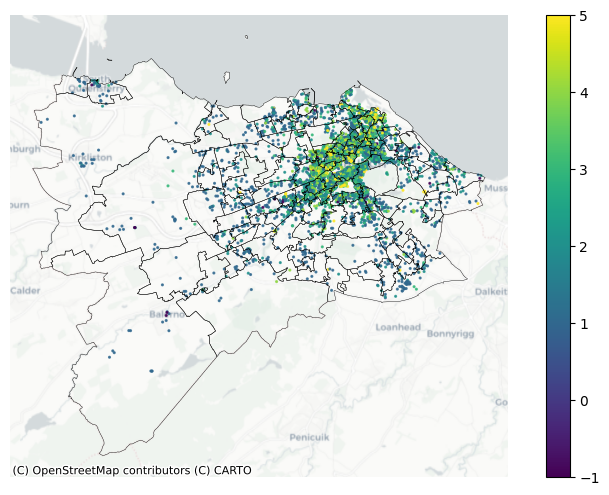

In [21]:
# Create a figure with the desired size
fig, ax = plt.subplots(figsize=(10, 6))

neighbourhoods.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.3, zorder=3)

# Plot the listings, colouring by gentrification score
df.plot(ax=ax, column='gentrification_prediction', markersize=1.5, alpha=0.8, zorder=2, legend=True)
#listings.plot(ax=ax, color='red', markersize=1, alpha=0.7, zorder=2)

# Add a basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=neighbourhoods.crs.to_string(), zorder=1)

# Adjust the axis for a clean appearance
ax.set_axis_off()

ax.figure.savefig("airbnb-bristol/listing_scores.png", dpi=300, bbox_inches="tight")

Lets also have a look at the listing cost

In [22]:
# Clean and convert 'price' column to float, handling commas and dollar signs
df['price_float'] = \
(
    df['price']
    .replace({None: np.nan})           # Replace None with NaN
    .str.replace(r'[\$,]', '', regex=True)  # Remove $ and , using regex
    .astype(float)                     # Convert to float
)

# Need a z score because there is a massive price
df['price_z'] = zscore(df['price_float'], nan_policy='omit')

# Even after normalising a couple of huge prices still skews loads, get rid of them
df.loc[df.price_z > 2, 'price'] = np.nan
df.loc[df.price_z > 2, 'price_z'] = np.nan

# Finally take account of the property size (bigger -> more expensive)
df['price_relative'] = df['price_z'] / df['accommodates']

#df.accommodates
#df.price_log

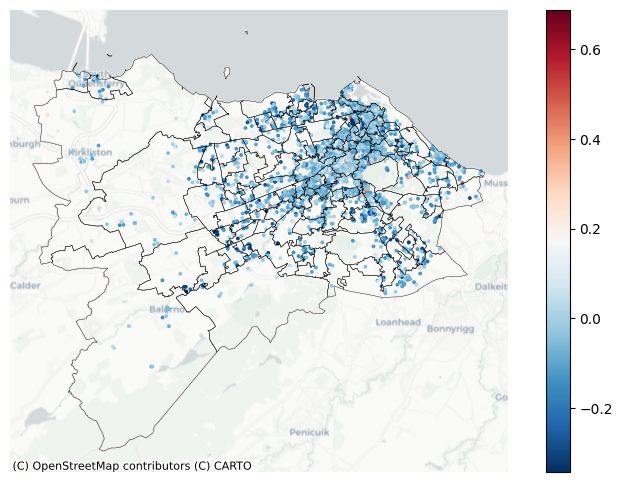

In [23]:
# Create a figure with the desired size
fig, ax = plt.subplots(figsize=(10, 6))

neighbourhoods.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.3, zorder=3)

# Plot the listings, colouring by gentrification score
df.plot(ax=ax, column='price_relative', markersize=3.0, alpha=1.0, zorder=2, legend=True,
    cmap="RdBu_r",  # Diverging color scheme
    vmin=df['price_relative'].min(),      # Optional: Define the range of z-scores
    vmax=df['price_relative'].max()
    )
#listings.plot(ax=ax, color='red', markersize=1, alpha=0.7, zorder=2)

# Add a basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=neighbourhoods.crs.to_string(), zorder=1)

# Adjust the axis for a clean appearance
ax.set_axis_off()


### Variability analysis

Load the three previously created files and examine the variability in the scores. Details of the variability analysis are in the [foursquare notebook](./2-gentrification_twitter.ipynb).

In [ ]:
assert len(matching_files) >= 3, "Print I'm expecting at least 3 gentrification files"
dfs = [gpd.read_file(base_dir+f).set_index("id", drop=True) for f in matching_files]
assert len(dfs) == len(matching_files)

# Check each row represents the same listing
for i in range(1, len(dfs)):
    assert dfs[i].index.equals(dfs[0].index), f"IDs in file {i} do not match those in file 0."
    assert dfs[i].name.equals(dfs[0].name), f"Names in file {i} do not match those in file 0."

 Merge the three dataframes so that we have 3 columns, one for each prediction


In [ ]:
merged_df = dfs[0].rename(columns={'gentrification_prediction': 'score_0',
                                  'explanation': 'explanation_0'})
for i in range(1, len(dfs)):
    merged_df = merged_df.merge(dfs[i].loc[:, ['gentrification_prediction', 'explanation']],
                                how='inner', left_index=True, right_index=True)
    merged_df = merged_df.rename(columns={'gentrification_prediction': f'score_{i}',
                                          'explanation': f'explanation_{i}'})
merged_df


Use **Fleiss' Kappa** as this compares all 'annotaters' (i.e. LLM attempts) simultaneously, rather than using Cohen's Kappa which only compares annotaters pairise (thanks ChatGPT)


In [ ]:
score_columns = [f"score_{i}" for i in range(len(dfs))]
explanation_columns = [f"explanation_{i}" for i in range(len(dfs))]

# Table with just the scores
ratings = merged_df[score_columns]

# Identify unique categories
categories = sorted(ratings.stack().unique())  # e.g., ['1', '2', '3', '4']
# Give the categories indices (0--4)
category_to_idx = {cat: i for i, cat in enumerate(categories)}

N = len(merged_df)              # Number of items
k = len(categories)      # Number of categories

# Create a count matrix (N x k), where each cell is the count of how many raters assigned that category
# (So each row has a 5-element array which counts the number of raters giving eaach category (1--5)
count_matrix = np.zeros((N, k), dtype=int)

for i, row in enumerate(ratings.values):
    for val in row:
        col_idx = category_to_idx[val]
        count_matrix[i, col_idx] += 1

# Now use fleiss_kappa from statsmodels directly
kappa_value = fleiss_kappa(count_matrix)
print("Fleiss' Kappa:", kappa_value)


The Fleiss' Kappa score of 0.74 suggests substantial agreement between the three LLM runs.